In [6]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

print(f"\n Task 1 - Data Exploration with Pandas")

# load the dataset
df = pd.read_csv("students.csv")

# display the first 5 rows
print("First 5 rows:")
print(df.head())

# display the structure and data types
print("\n Shape of the dataset:", df.shape)
print("\n Data types ofeach column:")
print(df.dtypes)

# display the summary statistics
print("\n Summary statistics:")
print(df.describe())

# count the no.of students passed and failed
print("\n Pass/Fail count:")
print(df["passed"].value_counts())

# finding the average score per subject separately for passed and failed students
subject_cols = ["math", "science", "english", "history", "pe"]

passed_students = df[df["passed"] == 1]
failed_students = df[df["passed"] == 0]

print("\n Average scores for passed students:")
print(passed_students[subject_cols].mean())

print("\n Average scores for failed students:")
print(failed_students[subject_cols].mean())

# finding the student with the highest overall average scross all 5 subjects
df["average_score"] = df[subject_cols].mean(axis=1)
best_index = df["average_score"].idxmax()
best_name = df.loc[best_index, "name"]
best_average = df.loc[best_index, "average_score"]

print(f"\n Student with the highest average score: {best_name} with an average of {best_average:.2f}")




 Task 1 - Data Exploration with Pandas
First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

 Shape of the dataset: (15, 9)

 Data types ofeach column:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype:


 Task 2 - Data Visualization with Matplotlib


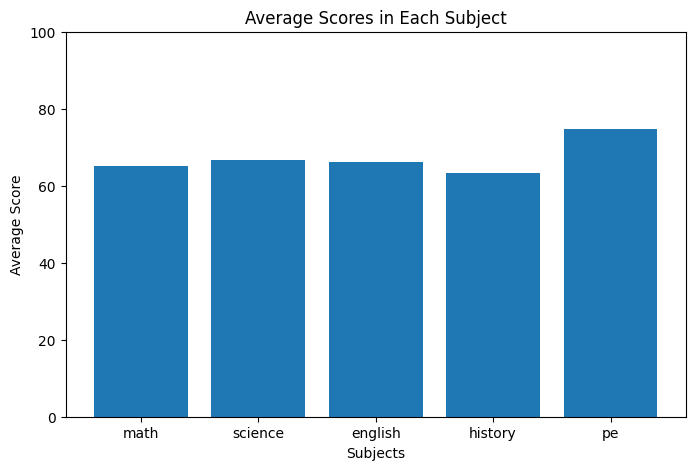

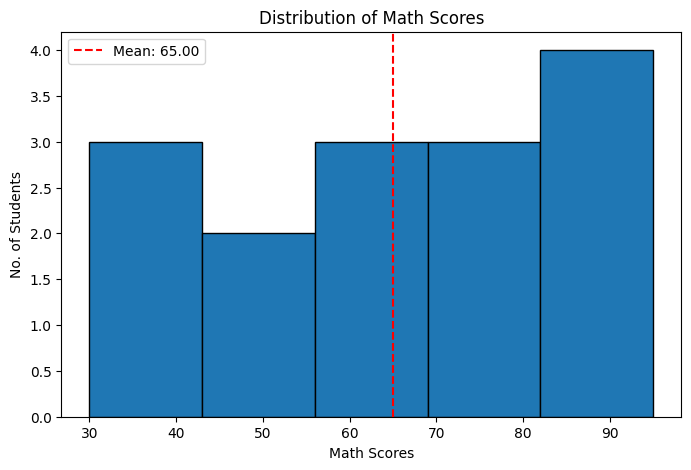

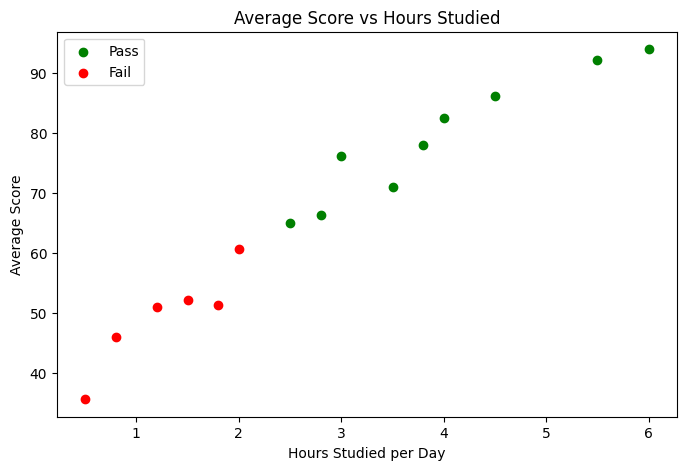

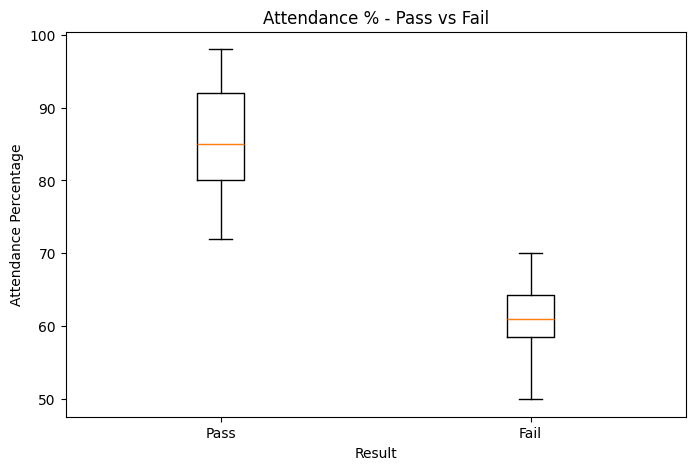

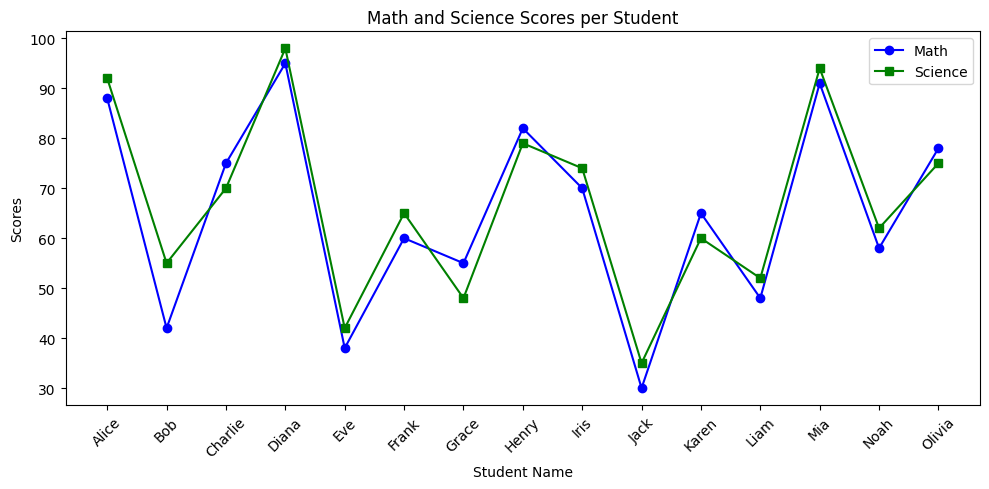

In [7]:
print(f"\n Task 2 - Data Visualization with Matplotlib")

# Plot 1: Bar chart showing average score in each subject

subject_avg = df[subject_cols].mean()

plt.figure(figsize=(8, 5))
plt.bar(subject_avg.index, subject_avg.values)
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.title("Average Scores in Each Subject")
plt.ylim(0, 100)
plt.savefig("plot1_bar.png")
plt.show()

# Plot 2: Histogram of math scores with a line showing the mean
mean_math = df["math"].mean()

plt.figure(figsize=(8, 5))
plt.hist(df["math"], bins=5, edgecolor="black")
plt.axvline(mean_math, color="red", linestyle="dashed", label=f"Mean: {mean_math:.2f}")
plt.xlabel("Math Scores")
plt.ylabel("No. of Students")
plt.title("Distribution of Math Scores")
plt.legend()
plt.savefig("plot2_histogram.png")
plt.show()

# Plot 3: Scatter plot- average score vs no.of hours studied per day, colored by pass/fail status
pass_df= df[df["passed"] == 1]
fail_df= df[df["passed"] == 0]

plt.figure(figsize=(8, 5))
plt.scatter(pass_df["study_hours_per_day"], pass_df["average_score"], color="green", label="Pass")
plt.scatter(fail_df["study_hours_per_day"], fail_df["average_score"], color="red", label="Fail")
plt.xlabel("Hours Studied per Day")
plt.ylabel("Average Score")
plt.title("Average Score vs Hours Studied")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()


# Plot 4: Box plot comparing attendance of passed and failed students
pass_attendance = df[df["passed"] == 1]["attendance_pct"].tolist()
fail_attendance = df[df["passed"] == 0]["attendance_pct"].tolist()

plt.figure(figsize=(8, 5))
plt.boxplot([pass_attendance, fail_attendance], labels=["Pass", "Fail"])
plt.ylabel("Attendance Percentage")
plt.xlabel("Result")
plt.title("Attendance % - Pass vs Fail")
plt.savefig("plot4_box.png")
plt.show()

# Plot 5: Line plot showing the math and science scores for every student
plt.figure(figsize=(10, 5))
plt.plot(df["name"], df["math"], marker="o", label="Math", color="blue")
plt.plot(df["name"], df["science"], marker="s", label="Science", color="green")
plt.xlabel("Student Name")
plt.ylabel("Scores")
plt.title("Math and Science Scores per Student")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()


 Task 3 - Data Visualization with Seaborn


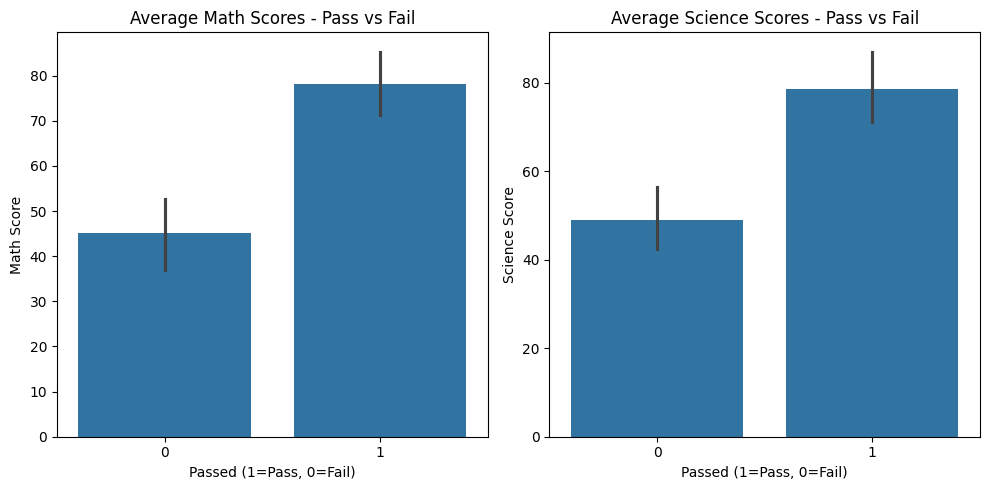

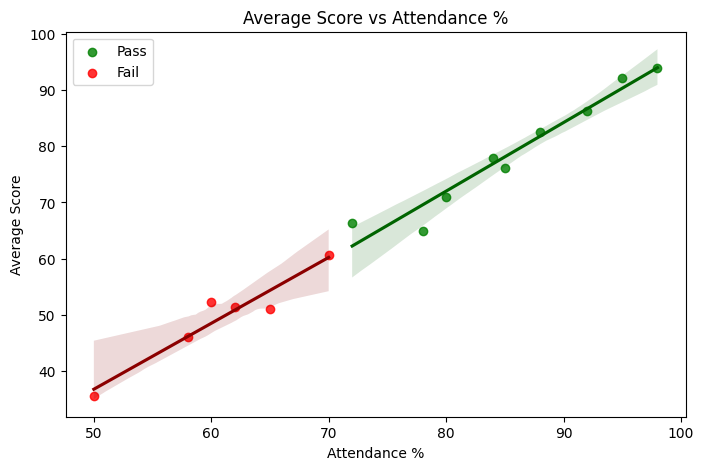

In [8]:
print(f"\n Task 3 - Data Visualization with Seaborn")

# Plot 1: Bar chart comparing average math & science scores for passed vs failed students
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

sns.barplot(x="passed", y="math", data=df, ax=ax1)
ax1.set_title("Average Math Scores - Pass vs Fail")
ax1.set_xlabel("Passed (1=Pass, 0=Fail)")
ax1.set_ylabel("Math Score")

sns.barplot(x="passed", y="science", data=df, ax=ax2)
ax2.set_title("Average Science Scores - Pass vs Fail")
ax2.set_xlabel("Passed (1=Pass, 0=Fail)")
ax2.set_ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

# Plot 2: scatter plot with regression line showing relationship between attendance and average score, colored by pass/fail status
fig, ax = plt.subplots(figsize=(8, 5))

sns.regplot(x="attendance_pct", y="average_score", data=df[df["passed"]==1], ax=ax, scatter_kws={"color": "green"}, line_kws={"color": "darkgreen"}, label="Pass")
sns.regplot(x="attendance_pct", y="average_score", data=df[df["passed"]==0], ax=ax, scatter_kws={"color": "red"}, line_kws={"color": "darkred"}, label="Fail")

ax.set_title("Average Score vs Attendance %")
ax.set_xlabel("Attendance %")
ax.set_ylabel("Average Score")
ax.legend()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

# Experience of using Seaborn vs Matplotlib:
# Seaborn provides quick and easy visualizations especially in this case for the bar chart and the regression scatter plot.
# Mathplotlib needed more code or manual work in terms of setting colors, lines and legends.
# Seaborn saves time for statisticalvisualizations while Matplotlib offers more customization and control over the plots.


 Task 4 - Machine Learning with Scikit-learn

 Training Accuracy: 100.00%
Test Accuracy: 100.00%

 Predictions on test students:
Jack: Actual: Fail, Predicted: Fail - Correct
Liam: Actual: Fail, Predicted: Fail - Correct
Alice: Actual: Pass, Predicted: Pass - Correct

n Feature importance (sorted):
english: 0.8125 (helps pass)
attendance_pct: 0.5219 (helps pass)
study_hours_per_day: 0.4844 (helps pass)
pe: 0.4750 (helps pass)
math: 0.4379 (helps pass)
science: 0.3230 (helps pass)
history: 0.2629 (helps pass)


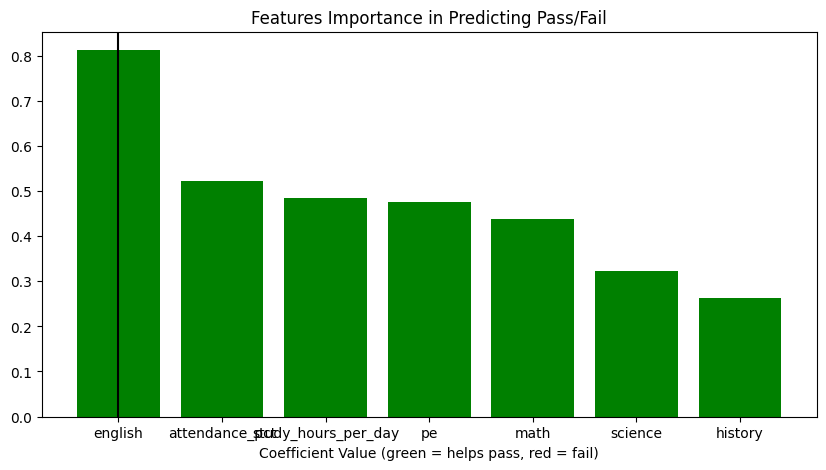


 New student prediction : Pass
Probability of failing: 9.20%
Probability of passing: 90.80%
Probability of failing: 9.20%


In [9]:
print(f"\n Task 4 - Machine Learning with Scikit-learn")

# building a classifier to predict whether a student will pass/fail

# setup the features (X) and target variable (y)
features = ["math", "science", "english", "history", "pe", "attendance_pct", "study_hours_per_day"]

X = df[features]
y = df["passed"]

# split into iraining set (80%) and test set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train a logistic regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

train_accuracy = model.score(X_train_scaled, y_train)
print(f"\n Training Accuracy: {train_accuracy * 100:.2f}%")

# evaluate the model on the test set
y_pred = model.predict(X_test_scaled)
test_accuracy = model.score(X_test_scaled, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

print("\n Predictions on test students:")
for i in range(len(y_test)):
    student_index = X_test.index[i]
    student_name = df.loc[student_index, "name"]
    actual = "Pass" if y_test.iloc[i] == 1 else "Fail"
    predicted = "Pass" if y_pred[i] == 1 else "Fail"
    correct = "Correct" if actual == predicted else "Wrong"
    print(f"{student_name}: Actual: {actual}, Predicted: {predicted} - {correct}")

# features importance
coefficients = model.coef_[0]

# pairing each feature name with its coefficient
coef_list = list(zip(features, coefficients))
coef_list.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nn Feature importance (sorted):")
for feature, coef in coef_list:
    effect = "helps pass" if coef > 0 else "fail"
    print(f"{feature}: {coef:.4f} ({effect})")

# bar chart to visualize the coefficients
feature_names = [f[0] for f in coef_list]
feature_values = [f[1] for f in coef_list]
bar_colors = ["green" if val > 0 else "red" for val in feature_values]

plt.figure(figsize=(10, 5))
plt.bar(feature_names, feature_values, color=bar_colors)
plt.axvline(0, color="black")
plt.title("Features Importance in Predicting Pass/Fail")
plt.xlabel("Coefficient Value (green = helps pass, red = fail)")
plt.savefig("plot8_feature_importance.png")
plt.show()

# prediction for a new student
new_student = [[75, 70, 68, 65, 80, 82, 3.2]] 
new_scaled = scaler.transform(new_student)
result = model.predict(new_scaled)[0]
proba = model.predict_proba(new_scaled)[0]

if result == 1:
    print("\n New student prediction : Pass")
else:
    print("\n New student prediction : Fail")

print(f"Probability of failing: {proba[0] * 100:.2f}%")
print(f"Probability of passing: {proba[1] * 100:.2f}%")
print(f"Probability of failing: {proba[0] * 100:.2f}%")

